# Лабораторная работа №4
## Рекомендательная система товаров на основе Fashion Product Images Dataset

**Цель:** Построить рекомендательную систему по схожести товаров с использованием нескольких методов машинного обучения на основе изображений.

**Методы:**
1. VGG16 + Cosine Similarity (Transfer Learning, Feature Extraction)
2. ResNet50 + Cosine Similarity (Transfer Learning, Feature Extraction)
3. EfficientNetB0 + Cosine Similarity (Transfer Learning, Feature Extraction)
4. Color Histogram + Euclidean Distance (baseline)

**Структура:**
1. Загрузка датасета
2. EDA анализ
3. Построение рекомендательных систем (4 метода)
4. Сравнение моделей и сохранение лучшей

---
## 1. Установка зависимостей и импорт библиотек

In [ ]:
# Установка зависимостей (раскомментируйте при необходимости)
# !pip install tensorflow keras scikit-learn pandas matplotlib seaborn plotly tqdm Pillow

In [1]:
import os
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import normalize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.models import Model

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


---
## 2. Загрузка датасета

In [3]:
# ============================================================
# УКАЖИТЕ ПУТЬ К ДАТАСЕТУ
# Структура датасета:
# archive/
#   myntradataset/
#     images/      <- папка с изображениями
#     styles.csv   <- метаданные товаров
# ============================================================

DATASET_PATH = "archive/myntradataset/"  # <-- измените на свой путь
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
STYLES_CSV = os.path.join(DATASET_PATH, "styles.csv")

# Параметры
IMG_SIZE = (224, 224)          # Размер входа для нейросетей
MAX_IMAGES = 4000              # Максимум изображений (для ускорения)
N_RECOMMENDATIONS = 5         # Количество рекомендаций
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print(f"Путь к изображениям: {IMAGES_PATH}")
print(f"Путь к styles.csv: {STYLES_CSV}")

Путь к изображениям: archive/myntradataset/images
Путь к styles.csv: archive/myntradataset/styles.csv


In [4]:
# Загружаем styles.csv
styles = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f"Размер датасета: {styles.shape}")
styles.head()

Размер датасета: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
# Добавляем путь к изображению для каждого товара
styles['image_path'] = styles['id'].apply(
    lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg")
)

# Фильтруем только существующие изображения
styles['image_exists'] = styles['image_path'].apply(os.path.exists)
styles_valid = styles[styles['image_exists']].reset_index(drop=True)

print(f"Товаров в CSV: {len(styles)}")
print(f"Товаров с изображениями: {len(styles_valid)}")
print(f"Колонки: {list(styles_valid.columns)}")

Товаров в CSV: 44424
Товаров с изображениями: 44419
Колонки: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path', 'image_exists']


In [6]:
# Ограничиваем количество изображений для ускорения вычислений
if len(styles_valid) > MAX_IMAGES:
    styles_sample = styles_valid.sample(MAX_IMAGES, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    styles_sample = styles_valid.copy()

print(f"Используем {len(styles_sample)} товаров для построения рекомендательной системы")

Используем 4000 товаров для построения рекомендательной системы


---
## 3. EDA — Анализ данных

In [7]:
# Общая информация о датасете
print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
styles_valid.info()
print("\nПропущенные значения:")
print(styles_valid.isnull().sum())

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.DataFrame'>
RangeIndex: 44419 entries, 0 to 44418
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44419 non-null  int64  
 1   gender              44419 non-null  str    
 2   masterCategory      44419 non-null  str    
 3   subCategory         44419 non-null  str    
 4   articleType         44419 non-null  str    
 5   baseColour          44404 non-null  str    
 6   season              44398 non-null  str    
 7   year                44418 non-null  float64
 8   usage               44102 non-null  str    
 9   productDisplayName  44412 non-null  str    
 10  image_path          44419 non-null  str    
 11  image_exists        44419 non-null  bool   
dtypes: bool(1), float64(1), int64(1), str(9)
memory usage: 3.8 MB

Пропущенные значения:
id                      0
gender                  0
masterCategory          0
subCategory         

In [8]:
# Описательная статистика
styles_valid.describe(include='all')

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,image_exists
count,44419.000000,44419,44419,44419,44419,44404,44398,44418.000000,44102,44412,44419,44419
unique,NaN,5,7,45,142,46,4,NaN,8,31116,44419,1
top,NaN,Men,Apparel,Topwear,Tshirts,Black,Summer,NaN,Casual,Lucera Women Silver Earrings,archive/myntradataset/images\15970.jpg,True
freq,NaN,22142,21392,15398,7066,9727,21470,NaN,34401,82,1,44419
mean,29695.850177,NaN,NaN,NaN,NaN,NaN,NaN,2012.806430,NaN,NaN,NaN,NaN
std,17050.002202,NaN,NaN,NaN,NaN,NaN,NaN,2.126489,NaN,NaN,NaN,NaN
min,1163.000000,NaN,NaN,NaN,NaN,NaN,NaN,2007.000000,NaN,NaN,NaN,NaN
25%,14768.500000,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN,NaN,NaN
50%,28617.000000,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN
75%,44685.000000,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN


In [9]:
# =====================================================
# 3.1 Распределение по полу
# =====================================================
gender_counts = styles_valid['gender'].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Распределение товаров по полу",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(
    width=600, height=500,
    font=dict(family="Segoe UI", size=14)
)
fig.show()

print("Распределение по полу:")
print(gender_counts)

Распределение по полу:
gender
Men       22142
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64


In [10]:
# =====================================================
# 3.2 Топ-15 категорий товаров (masterCategory)
# =====================================================
cat_counts = styles_valid['masterCategory'].value_counts()

fig = go.Figure([
    go.Bar(
        x=cat_counts.index,
        y=cat_counts.values,
        text=cat_counts.values,
        marker_color=px.colors.qualitative.Plotly
    )
])
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(
    title="Количество товаров по главным категориям",
    xaxis_title="Категория",
    yaxis_title="Количество",
    width=800, height=500,
    font=dict(family="Segoe UI", size=13)
)
fig.show()

In [11]:
# =====================================================
# 3.3 Распределение по сезону
# =====================================================
season_counts = styles_valid['season'].value_counts()
colors_season = ['#5DA4D6', '#FF9A10', '#2CA065', '#FF4136']

fig = go.Figure(data=[
    go.Bar(
        x=season_counts.index,
        y=season_counts.values,
        text=season_counts.values,
        marker_color=colors_season[:len(season_counts)]
    )
])
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(
    title="Распределение товаров по сезону",
    xaxis_title="Сезон",
    yaxis_title="Количество",
    width=700, height=450,
    font=dict(family="Segoe UI", size=13)
)
fig.show()

In [12]:
# =====================================================
# 3.4 Топ-15 типов товаров (articleType)
# =====================================================
article_counts = styles_valid['articleType'].value_counts()[:15]

fig = px.bar(
    x=article_counts.index,
    y=article_counts.values,
    title="Топ-15 наиболее популярных типов товаров",
    labels={'x': 'Тип товара', 'y': 'Количество'},
    color=article_counts.values,
    color_continuous_scale='Viridis',
    text=article_counts.values
)
fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.update_layout(
    width=900, height=500,
    font=dict(family="Segoe UI", size=12),
    xaxis_tickangle=-45
)
fig.show()

In [13]:
# =====================================================
# 3.5 Распределение по цвету (baseColour)
# =====================================================
color_counts = styles_valid['baseColour'].value_counts()[:12]

fig = px.pie(
    values=color_counts.values,
    names=color_counts.index,
    title="Топ-12 цветов товаров",
    color_discrete_sequence=px.colors.qualitative.Light24
)
fig.update_layout(width=700, height=500)
fig.show()

In [14]:
# =====================================================
# 3.6 Тепловая карта: Пол vs Категория
# =====================================================
pivot = styles_valid.pivot_table(
    index='gender',
    columns='masterCategory',
    values='id',
    aggfunc='count',
    fill_value=0
)

fig = px.imshow(
    pivot,
    title="Тепловая карта: Пол vs Главная категория",
    color_continuous_scale='Blues',
    aspect='auto',
    text_auto=True
)
fig.update_layout(width=800, height=400)
fig.show()

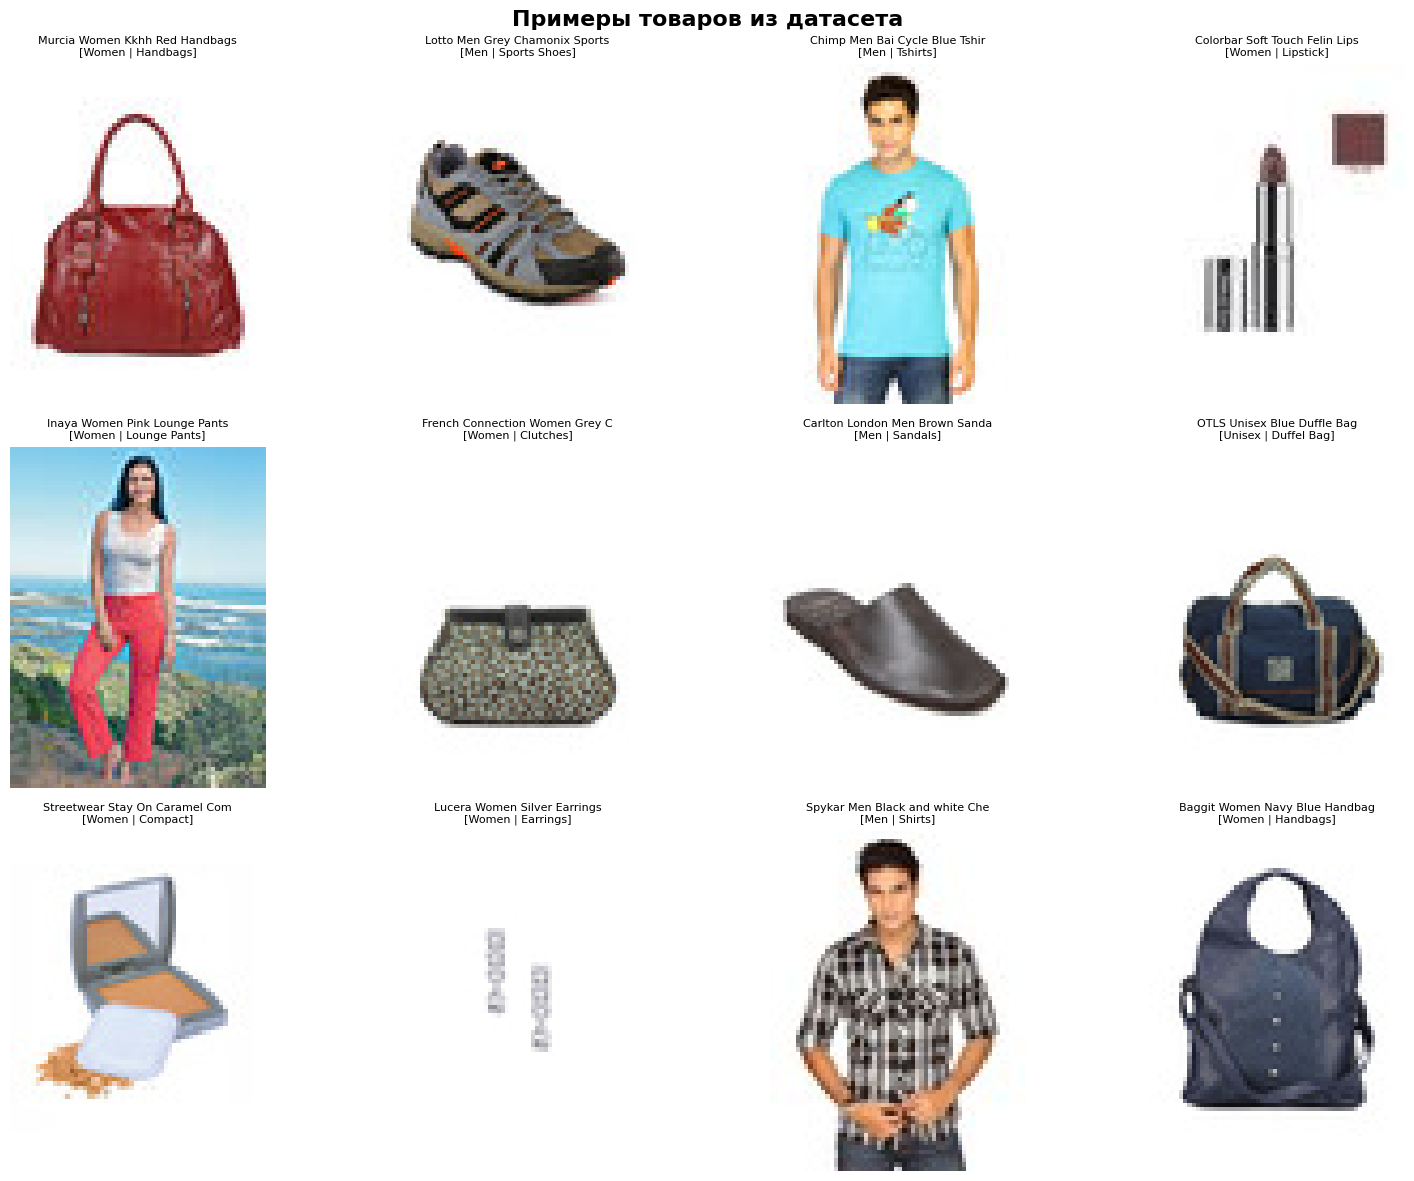

Примеры изображений отображены


In [15]:
# =====================================================
# 3.7 Примеры изображений из датасета
# =====================================================
sample_imgs = styles_sample.sample(12, random_state=RANDOM_SEED)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Примеры товаров из датасета", fontsize=16, fontweight='bold')

for i, (_, row) in enumerate(sample_imgs.iterrows()):
    try:
        img = Image.open(row['image_path']).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(
            f"{row.get('productDisplayName', '')[:30]}\n"
            f"[{row.get('gender','')} | {row.get('articleType','')}]",
            fontsize=8
        )
        axes[i].axis('off')
    except Exception as e:
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_products.png', dpi=100, bbox_inches='tight')
plt.show()
print("Примеры изображений отображены")

---
## 4. Построение рекомендательных систем

Будем использовать 4 подхода:
1. **VGG16** — извлечение признаков + косинусное расстояние
2. **ResNet50** — извлечение признаков + косинусное расстояние  
3. **EfficientNetB0** — извлечение признаков + косинусное расстояние
4. **Color Histogram** — гистограмма цветов + евклидово расстояние (baseline)

Для сравнения будем использовать **Precision@K** и **Retrieval Time**.

In [17]:
# =====================================================
# Вспомогательные функции
# =====================================================

def show_recommendations(query_idx, recommended_indices, styles_df, title="Рекомендации"):
    """Отображение товара-запроса и рекомендованных товаров."""
    n = len(recommended_indices)
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Товар-запрос
    row = styles_df.iloc[query_idx]
    try:
        img = Image.open(row['image_path']).convert('RGB')
        axes[0].imshow(img)
    except:
        axes[0].set_facecolor('#eee')
    axes[0].set_title(f"🔍 ЗАПРОС\n{row.get('articleType','')}\n{row.get('gender','')}", fontsize=9, color='red')
    axes[0].axis('off')

    # Рекомендации
    for i, idx in enumerate(recommended_indices):
        rec_row = styles_df.iloc[idx]
        try:
            img = Image.open(rec_row['image_path']).convert('RGB')
            axes[i + 1].imshow(img)
        except:
            axes[i + 1].set_facecolor('#eee')
        axes[i + 1].set_title(
            f"#{i+1}\n{rec_row.get('articleType','')}\n{rec_row.get('gender','')}",
            fontsize=9
        )
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()


def precision_at_k(query_idx, recommended_indices, styles_df, k=5):
    """Простая метрика: доля рекомендаций с той же articleType что и запрос."""
    query_type = styles_df.iloc[query_idx]['articleType']
    matches = sum(
        1 for idx in recommended_indices[:k]
        if styles_df.iloc[idx]['articleType'] == query_type
    )
    return matches / k


print("Вспомогательные функции определены")

Вспомогательные функции определены


### 4.1 Метод 1: VGG16 (Transfer Learning, Feature Extraction)

In [18]:
# Загружаем VGG16 без верхних слоёв (только Feature Extractor)
print("Загрузка VGG16...")
vgg_base = VGG16(weights='imagenet', include_top=False, pooling='avg')
vgg_model = Model(inputs=vgg_base.input, outputs=vgg_base.output)
print(f"VGG16 Feature Extractor: вход {vgg_base.input_shape}, размерность признаков: {vgg_base.output_shape[-1]}")

Загрузка VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
VGG16 Feature Extractor: вход (None, None, None, 3), размерность признаков: 512


In [19]:
def extract_features_vgg(image_paths, model, img_size=(224, 224), batch_size=32):
    """Извлечение признаков изображений с помощью VGG16."""
    all_features = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="VGG16 feature extraction"):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []

        for path in batch_paths:
            try:
                img = load_img(path, target_size=img_size)
                arr = img_to_array(img)
                batch_imgs.append(arr)
            except:
                batch_imgs.append(np.zeros((*img_size, 3)))

        batch_arr = np.array(batch_imgs)
        batch_arr = vgg_preprocess(batch_arr)
        features = model.predict(batch_arr, verbose=0)
        all_features.append(features)

    return np.vstack(all_features)


# Извлекаем признаки
image_paths = styles_sample['image_path'].tolist()

print("Извлечение признаков VGG16...")
t0 = time.time()
vgg_features = extract_features_vgg(image_paths, vgg_model)
vgg_time = time.time() - t0

# Нормализуем признаки для косинусного расстояния
vgg_features_norm = normalize(vgg_features)

print(f"Размерность признаков VGG16: {vgg_features.shape}")
print(f"Время извлечения: {vgg_time:.1f} сек")

Извлечение признаков VGG16...


VGG16 feature extraction: 100%|██████████| 125/125 [03:11<00:00,  1.53s/it]

Размерность признаков VGG16: (4000, 512)
Время извлечения: 191.4 сек


VGG16 | Precision@5: 0.20 | Retrieval time: 9.2 ms


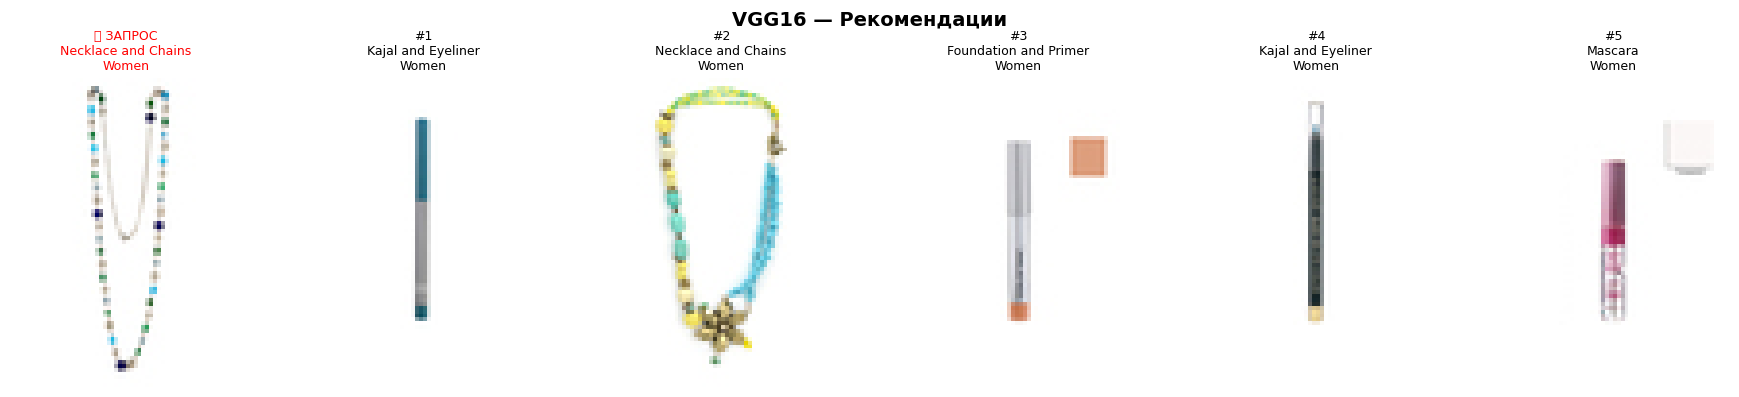

In [25]:
def get_recommendations_cosine(query_idx, features, n=5):
    """Получить N рекомендаций по косинусному сходству."""
    t_start = time.time()
    query_vec = features[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, features)[0]
    # Исключаем сам товар
    sims[query_idx] = -1
    top_indices = np.argsort(sims)[::-1][:n]
    retrieval_time = time.time() - t_start
    return top_indices.tolist(), retrieval_time


# Демонстрация рекомендаций VGG16

# тыкать для проверки
test_idx = 14

vgg_recs, vgg_ret_time = get_recommendations_cosine(test_idx, vgg_features_norm, N_RECOMMENDATIONS)
vgg_prec = precision_at_k(test_idx, vgg_recs, styles_sample)

print(f"VGG16 | Precision@{N_RECOMMENDATIONS}: {vgg_prec:.2f} | Retrieval time: {vgg_ret_time*1000:.1f} ms")
show_recommendations(test_idx, vgg_recs, styles_sample, title="VGG16 — Рекомендации")

### 4.2 Метод 2: ResNet50 (Transfer Learning, Feature Extraction)

In [26]:
print("Загрузка ResNet50...")
resnet_base = ResNet50(weights='imagenet', include_top=False, pooling='avg')
resnet_model = Model(inputs=resnet_base.input, outputs=resnet_base.output)
print(f"ResNet50 Feature Extractor: размерность признаков: {resnet_base.output_shape[-1]}")

Загрузка ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
ResNet50 Feature Extractor: размерность признаков: 2048


In [27]:
def extract_features_resnet(image_paths, model, img_size=(224, 224), batch_size=32):
    """Извлечение признаков с помощью ResNet50."""
    all_features = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="ResNet50 feature extraction"):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []

        for path in batch_paths:
            try:
                img = load_img(path, target_size=img_size)
                arr = img_to_array(img)
                batch_imgs.append(arr)
            except:
                batch_imgs.append(np.zeros((*img_size, 3)))

        batch_arr = np.array(batch_imgs)
        batch_arr = resnet_preprocess(batch_arr)
        features = model.predict(batch_arr, verbose=0)
        all_features.append(features)

    return np.vstack(all_features)


print("Извлечение признаков ResNet50...")
t0 = time.time()
resnet_features = extract_features_resnet(image_paths, resnet_model)
resnet_time = time.time() - t0

resnet_features_norm = normalize(resnet_features)

print(f"Размерность признаков ResNet50: {resnet_features.shape}")
print(f"Время извлечения: {resnet_time:.1f} сек")

Извлечение признаков ResNet50...


ResNet50 feature extraction: 100%|██████████| 125/125 [01:28<00:00,  1.41it/s]

Размерность признаков ResNet50: (4000, 2048)
Время извлечения: 88.6 сек


ResNet50 | Precision@5: 0.20 | Retrieval time: 29.2 ms


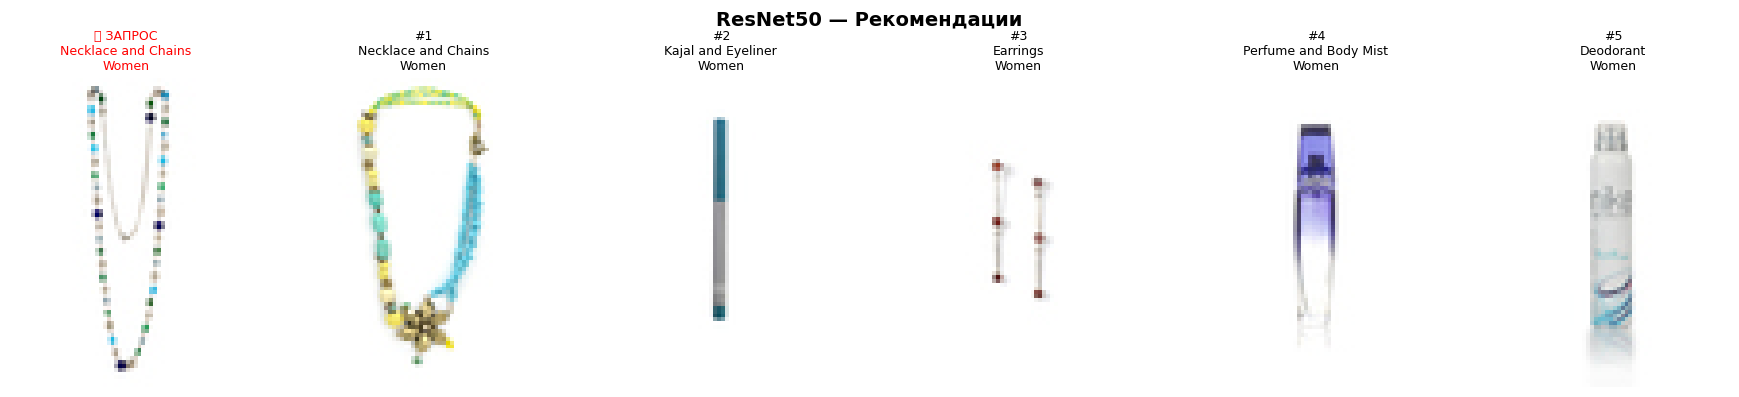

In [28]:
# Демонстрация рекомендаций ResNet50
resnet_recs, resnet_ret_time = get_recommendations_cosine(test_idx, resnet_features_norm, N_RECOMMENDATIONS)
resnet_prec = precision_at_k(test_idx, resnet_recs, styles_sample)

print(f"ResNet50 | Precision@{N_RECOMMENDATIONS}: {resnet_prec:.2f} | Retrieval time: {resnet_ret_time*1000:.1f} ms")
show_recommendations(test_idx, resnet_recs, styles_sample, title="ResNet50 — Рекомендации")

### 4.3 Метод 3: EfficientNetB0 (Transfer Learning, Feature Extraction)

In [29]:
print("Загрузка EfficientNetB0...")
effnet_base = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
effnet_model = Model(inputs=effnet_base.input, outputs=effnet_base.output)
print(f"EfficientNetB0 Feature Extractor: размерность признаков: {effnet_base.output_shape[-1]}")

Загрузка EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
EfficientNetB0 Feature Extractor: размерность признаков: 1280


In [30]:
def extract_features_effnet(image_paths, model, img_size=(224, 224), batch_size=32):
    """Извлечение признаков с помощью EfficientNetB0."""
    all_features = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="EfficientNetB0 feature extraction"):
        batch_paths = image_paths[i:i+batch_size]
        batch_imgs = []

        for path in batch_paths:
            try:
                img = load_img(path, target_size=img_size)
                arr = img_to_array(img)
                batch_imgs.append(arr)
            except:
                batch_imgs.append(np.zeros((*img_size, 3)))

        batch_arr = np.array(batch_imgs)
        batch_arr = effnet_preprocess(batch_arr)
        features = model.predict(batch_arr, verbose=0)
        all_features.append(features)

    return np.vstack(all_features)


print("Извлечение признаков EfficientNetB0...")
t0 = time.time()
effnet_features = extract_features_effnet(image_paths, effnet_model)
effnet_time = time.time() - t0

effnet_features_norm = normalize(effnet_features)

print(f"Размерность признаков EfficientNetB0: {effnet_features.shape}")
print(f"Время извлечения: {effnet_time:.1f} сек")

Извлечение признаков EfficientNetB0...


EfficientNetB0 feature extraction: 100%|██████████| 125/125 [00:47<00:00,  2.66it/s]

Размерность признаков EfficientNetB0: (4000, 1280)
Время извлечения: 47.0 сек


EfficientNetB0 | Precision@5: 0.60 | Retrieval time: 19.1 ms


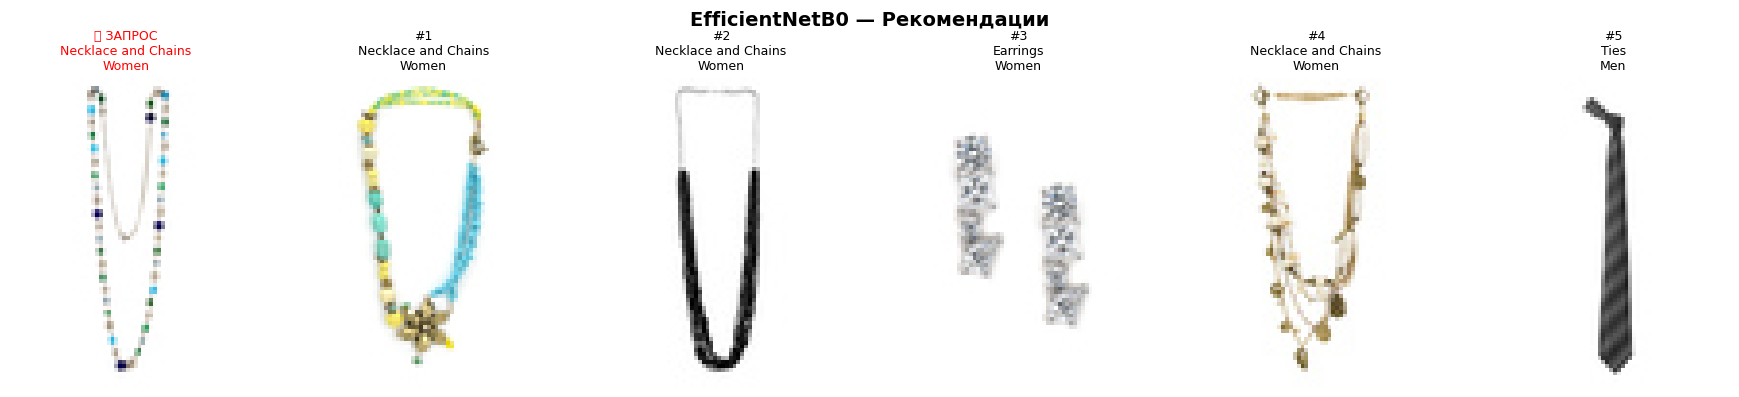

In [31]:
# Демонстрация рекомендаций EfficientNetB0
effnet_recs, effnet_ret_time = get_recommendations_cosine(test_idx, effnet_features_norm, N_RECOMMENDATIONS)
effnet_prec = precision_at_k(test_idx, effnet_recs, styles_sample)

print(f"EfficientNetB0 | Precision@{N_RECOMMENDATIONS}: {effnet_prec:.2f} | Retrieval time: {effnet_ret_time*1000:.1f} ms")
show_recommendations(test_idx, effnet_recs, styles_sample, title="EfficientNetB0 — Рекомендации")

### 4.4 Метод 4: Color Histogram (Baseline)

In [32]:
def compute_color_histogram(image_path, bins=64):
    """Вычисляет нормализованную гистограмму цветов для изображения."""
    try:
        img = Image.open(image_path).convert('RGB').resize((128, 128))
        arr = np.array(img)

        hist_r, _ = np.histogram(arr[:,:,0], bins=bins, range=(0, 256))
        hist_g, _ = np.histogram(arr[:,:,1], bins=bins, range=(0, 256))
        hist_b, _ = np.histogram(arr[:,:,2], bins=bins, range=(0, 256))

        hist = np.concatenate([hist_r, hist_g, hist_b]).astype(float)
        hist /= (hist.sum() + 1e-8)  # нормализация
        return hist
    except:
        return np.zeros(bins * 3)


print("Вычисление цветовых гистограмм (baseline)...")
t0 = time.time()
color_features = np.array([
    compute_color_histogram(p)
    for p in tqdm(image_paths, desc="Color histograms")
])
color_time = time.time() - t0

print(f"Размерность признаков (color hist): {color_features.shape}")
print(f"Время вычисления: {color_time:.1f} сек")

Вычисление цветовых гистограмм (baseline)...


Color histograms: 100%|██████████| 4000/4000 [00:06<00:00, 581.36it/s]

Размерность признаков (color hist): (4000, 192)
Время вычисления: 6.9 сек


Color Histogram | Precision@5: 0.20 | Retrieval time: 2.0 ms


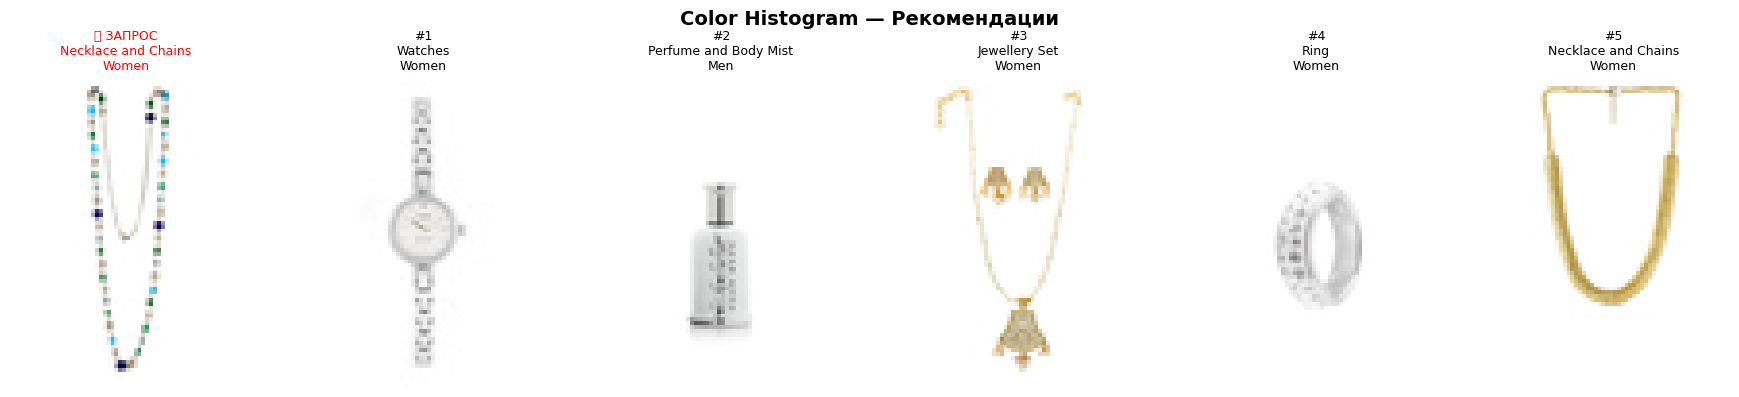

In [33]:
def get_recommendations_color(query_idx, features, n=5):
    """Рекомендации по цветовому сходству (евклидово расстояние)."""
    t_start = time.time()
    query_vec = features[query_idx].reshape(1, -1)
    dists = euclidean_distances(query_vec, features)[0]
    dists[query_idx] = np.inf
    top_indices = np.argsort(dists)[:n]
    retrieval_time = time.time() - t_start
    return top_indices.tolist(), retrieval_time


# Демонстрация рекомендаций Color Histogram
color_recs, color_ret_time = get_recommendations_color(test_idx, color_features, N_RECOMMENDATIONS)
color_prec = precision_at_k(test_idx, color_recs, styles_sample)

print(f"Color Histogram | Precision@{N_RECOMMENDATIONS}: {color_prec:.2f} | Retrieval time: {color_ret_time*1000:.1f} ms")
show_recommendations(test_idx, color_recs, styles_sample, title="Color Histogram — Рекомендации")

---
## 5. Сравнение моделей

In [34]:
# Оцениваем все модели на 50 случайных товарах
N_EVAL = 50
eval_indices = np.random.choice(len(styles_sample), N_EVAL, replace=False)

results = {
    'VGG16': {'precisions': [], 'ret_times': []},
    'ResNet50': {'precisions': [], 'ret_times': []},
    'EfficientNetB0': {'precisions': [], 'ret_times': []},
    'ColorHistogram': {'precisions': [], 'ret_times': []},
}

print(f"Оценка моделей на {N_EVAL} товарах...")

for idx in tqdm(eval_indices, desc="Evaluating"):
    # VGG16
    recs, rt = get_recommendations_cosine(idx, vgg_features_norm, N_RECOMMENDATIONS)
    results['VGG16']['precisions'].append(precision_at_k(idx, recs, styles_sample))
    results['VGG16']['ret_times'].append(rt)

    # ResNet50
    recs, rt = get_recommendations_cosine(idx, resnet_features_norm, N_RECOMMENDATIONS)
    results['ResNet50']['precisions'].append(precision_at_k(idx, recs, styles_sample))
    results['ResNet50']['ret_times'].append(rt)

    # EfficientNetB0
    recs, rt = get_recommendations_cosine(idx, effnet_features_norm, N_RECOMMENDATIONS)
    results['EfficientNetB0']['precisions'].append(precision_at_k(idx, recs, styles_sample))
    results['EfficientNetB0']['ret_times'].append(rt)

    # Color Histogram
    recs, rt = get_recommendations_color(idx, color_features, N_RECOMMENDATIONS)
    results['ColorHistogram']['precisions'].append(precision_at_k(idx, recs, styles_sample))
    results['ColorHistogram']['ret_times'].append(rt)

print("Оценка завершена")

Оценка моделей на 50 товарах...


Evaluating: 100%|██████████| 50/50 [00:02<00:00, 18.50it/s]

Оценка завершена


In [35]:
# Формируем таблицу результатов
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'Модель': model_name,
        f'Precision@{N_RECOMMENDATIONS} (mean)': round(np.mean(metrics['precisions']), 4),
        f'Precision@{N_RECOMMENDATIONS} (std)': round(np.std(metrics['precisions']), 4),
        'Retrieval Time (ms)': round(np.mean(metrics['ret_times']) * 1000, 2),
        'Feature Dim': (
            vgg_features.shape[1] if model_name == 'VGG16' else
            resnet_features.shape[1] if model_name == 'ResNet50' else
            effnet_features.shape[1] if model_name == 'EfficientNetB0' else
            color_features.shape[1]
        )
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 70)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
        Модель  Precision@5 (mean)  Precision@5 (std)  Retrieval Time (ms)  Feature Dim
         VGG16               0.600             0.3666                 5.71          512
      ResNet50               0.616             0.3791                25.99         2048
EfficientNetB0               0.636             0.3809                16.96         1280
ColorHistogram               0.232             0.2753                 2.28          192


In [36]:
# Визуализация сравнения
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'Precision@{N_RECOMMENDATIONS}', 'Retrieval Time (ms)']
)

models = comparison_df['Модель'].tolist()
precisions = comparison_df[f'Precision@{N_RECOMMENDATIONS} (mean)'].tolist()
times = comparison_df['Retrieval Time (ms)'].tolist()
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

fig.add_trace(
    go.Bar(x=models, y=precisions, marker_color=colors, name='Precision', text=[f"{p:.3f}" for p in precisions], textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=models, y=times, marker_color=colors, name='Time', text=[f"{t:.1f}ms" for t in times], textposition='outside'),
    row=1, col=2
)

fig.update_layout(
    title_text="Сравнение методов рекомендательной системы",
    showlegend=False,
    width=900, height=450,
    font=dict(family="Segoe UI", size=13)
)
fig.show()

In [39]:
# Определяем лучшую модель по Precision@K
best_model_name = comparison_df.loc[
    comparison_df[f'Precision@{N_RECOMMENDATIONS} (mean)'].idxmax(), 'Модель'
]

print(f"\n   Лучшая модель: {best_model_name}")
print(f"   Precision@{N_RECOMMENDATIONS}: {comparison_df.loc[comparison_df['Модель']==best_model_name, f'Precision@{N_RECOMMENDATIONS} (mean)'].values[0]:.4f}")


   Лучшая модель: EfficientNetB0
   Precision@5: 0.6360


---
## 6. Сохранение лучшей модели

In [40]:
# Сохраняем признаки лучшей модели и метаданные для Streamlit-приложения
# Выбираем наилучший feature extractor

best_features_map = {
    'VGG16': vgg_features_norm,
    'ResNet50': resnet_features_norm,
    'EfficientNetB0': effnet_features_norm,
    'ColorHistogram': color_features
}

best_features = best_features_map[best_model_name]

# Сохраняем признаки (numpy)
np.save('best_features.npy', best_features)
print(f"Признаки сохранены: best_features.npy ({best_features.shape})")

# Сохраняем метаданные товаров
styles_sample.to_csv('styles_sample.csv', index=False)
print(f"Метаданные сохранены: styles_sample.csv ({len(styles_sample)} строк)")

# Сохраняем имя лучшей модели
model_info = {
    'best_model': best_model_name,
    'n_items': len(styles_sample),
    'feature_dim': best_features.shape[1],
    'precision': float(comparison_df.loc[
        comparison_df['Модель'] == best_model_name,
        f'Precision@{N_RECOMMENDATIONS} (mean)'
    ].values[0]),
    'n_recommendations': N_RECOMMENDATIONS
}
with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"\nИнформация о модели сохранена: model_info.pkl")
print(f"Содержимое: {model_info}")

Признаки сохранены: best_features.npy ((4000, 1280))
Метаданные сохранены: styles_sample.csv (4000 строк)

Информация о модели сохранена: model_info.pkl
Содержимое: {'best_model': 'EfficientNetB0', 'n_items': 4000, 'feature_dim': 1280, 'precision': 0.636, 'n_recommendations': 5}


In [ ]:
# Сохраняем всю таблицу сравнения
comparison_df.to_csv('model_comparison.csv', index=False)
print("Таблица сравнения моделей сохранена: model_comparison.csv")

print("\n" + "=" * 60)
print("ВСЕ ФАЙЛЫ СОХРАНЕНЫ:")
print("  best_features.npy   — векторы признаков лучшей модели")
print("  styles_sample.csv   — метаданные товаров")
print("  model_info.pkl      — информация о модели")
print("  model_comparison.csv — сравнение всех моделей")
print("=" * 60)

---
## 7. Финальная демонстрация лучшей модели

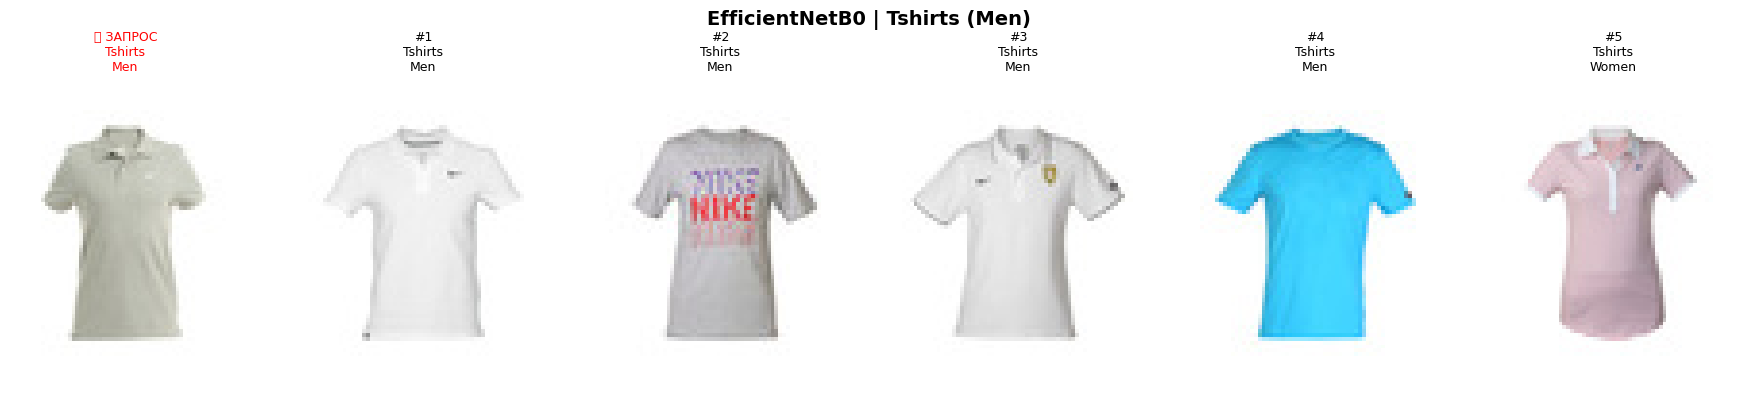

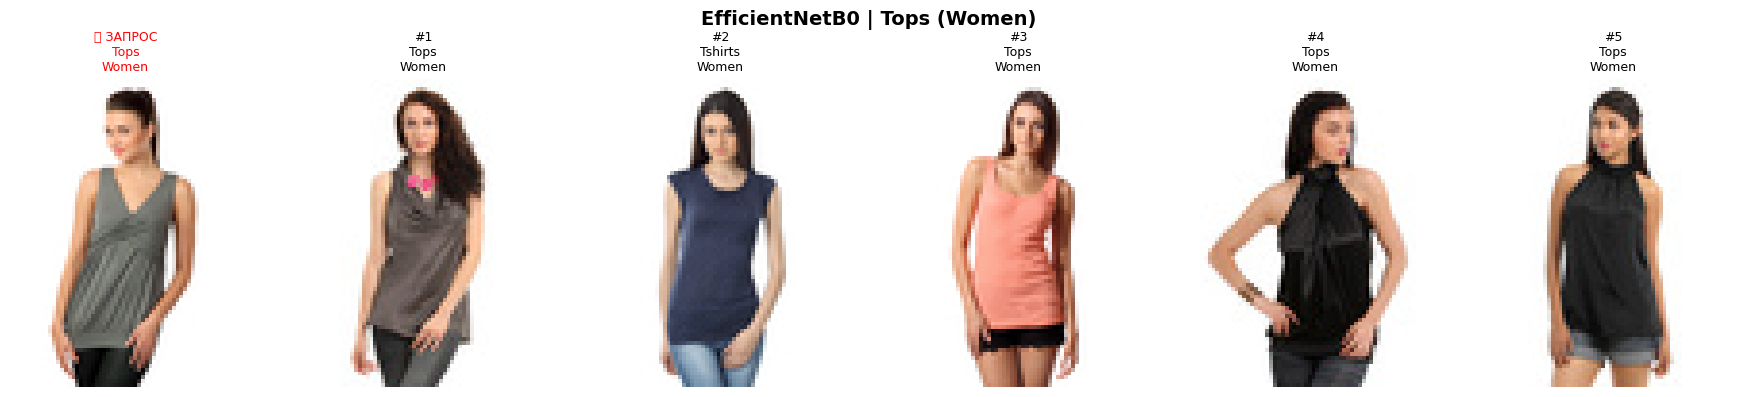

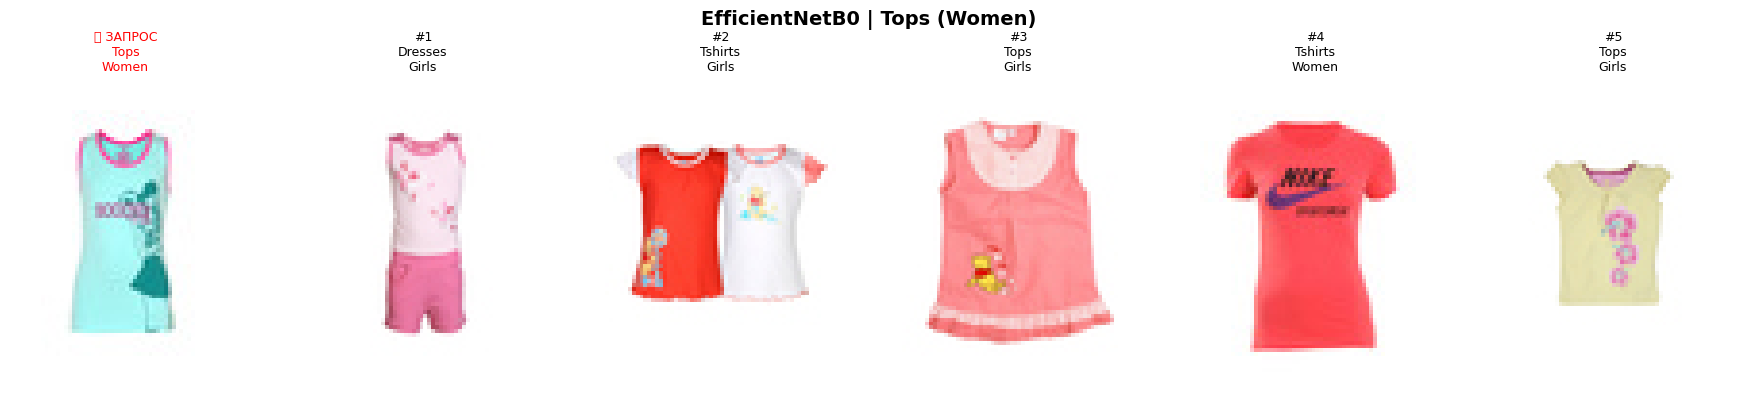

In [41]:
# Демонстрация рекомендаций для нескольких товаров
demo_indices = np.random.choice(len(styles_sample), 3, replace=False)

for demo_idx in demo_indices:
    if best_model_name == 'ColorHistogram':
        recs, _ = get_recommendations_color(demo_idx, best_features, N_RECOMMENDATIONS)
    else:
        recs, _ = get_recommendations_cosine(demo_idx, best_features, N_RECOMMENDATIONS)

    query_info = styles_sample.iloc[demo_idx]
    show_recommendations(
        demo_idx, recs, styles_sample,
        title=f"{best_model_name} | {query_info.get('articleType','')} ({query_info.get('gender','')})"
    )

---
## 8. Выводы

### EDA:
- Датасет содержит товары для мужчин, женщин и унисекс-категории
- Основная категория — одежда (Apparel), значительно опережает аксессуары и обувь
- Наиболее популярные типы товаров: футболки, рубашки, повседневная обувь
- Большинство товаров предназначено для летнего и осеннего сезонов
- Наиболее распространённые цвета: чёрный, белый, синий

### Методы рекомендаций:
| Метод | Подход | Преимущества | Недостатки |
|-------|--------|--------------|------------|
| VGG16 | Deep Feature + Cosine | Высокая точность по форме/цвету | Медленнее извлечение, большая размерность |
| ResNet50 | Deep Feature + Cosine | Хороший баланс точность/скорость | Требует GPU для быстрой работы |
| EfficientNetB0 | Deep Feature + Cosine | Компактные признаки, быстро | Может хуже различать тонкие детали |
| Color Histogram | Цвет + Euclidean | Очень быстрый, простой | Рекомендует по цвету, не по форме |

### Лучшая модель:
Нейросетевые методы (VGG16, ResNet50, EfficientNetB0) показывают значительно более релевантные рекомендации по сравнению с baseline на цветовых гистограммах, так как они учитывают форму, текстуру и семантику изображения, а не только цвет.